<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
from io import StringIO

# Alternative URL for the Sentiment140 dataset from Kaggle
# This URL points to the raw CSV file from a Kaggle dataset
dataset_url = 'https://raw.githubusercontent.com/AnupamBais/Sentiment-Analysis-on-Tweets/main/training.1600000.processed.noemoticon.csv'

print(f"Downloading Sentiment140 dataset from {dataset_url}...")
response = requests.get(dataset_url)
response.raise_for_status() # Raise an exception for bad status codes
print("Download complete. Loading into DataFrame...")

# The dataset does not have a header, so we define column names
column_names = ['sentiment', 'id', 'date', 'query', 'user', 'text']

# Load the dataset into a pandas DataFrame
# The dataset uses ISO-8859-1 encoding
df_sentiment140 = pd.read_csv(StringIO(response.text), encoding='ISO-8859-1', names=column_names)

print("DataFrame loaded successfully.")

HTTPError: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/AnupamBais/Sentiment-Analysis-on-Tweets/main/training.1600000.processed.noemoticon.csv

### Step 1: Install the Kaggle API client

First, we need to install the Kaggle Python package. This might already be installed in Colab, but it's good practice to ensure it's available.

In [ ]:
# Install the Kaggle API client
%pip install kaggle

### Step 2: Set up Kaggle API Credentials

To use the Kaggle API, you need an API token. Follow these steps:

1.  Go to [Kaggle](https://www.kaggle.com/) and log in.
2.  Click on your profile picture in the top right corner, then select 'Your Profile'.
3.  Navigate to the 'Account' tab.
4.  Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
5.  Open the `kaggle.json` file with a text editor. It contains your username and key, for example:
    ```json
    {"username":"your_username","key":"your_api_key"}
    ```
6.  In Colab, go to the 'Secrets' tab (🔑 icon on the left panel).
7.  Add two new secrets: one named `KAGGLE_USERNAME` with your Kaggle username as the value, and another named `KAGGLE_KEY` with your Kaggle API key as the value.

Once your secrets are set up, run the following cell to make them accessible to the Kaggle API.

In [ ]:
import os
from google.colab import userdata

# Set Kaggle API credentials as environment variables
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Kaggle API credentials configured.")

SecretNotFoundError: Secret KAGGLE_USERNAME does not exist.

### Step 3: Download the Sentiment140 dataset

Now we can use the Kaggle API to download the dataset. The dataset identifier for Sentiment140 is `kazanova/sentiment140`.

In [ ]:
# Download the dataset
# The -p . ensures it downloads to the current directory
!kaggle datasets download -d kazanova/sentiment140 -p .

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 116MB/s]



### Step 4: Unzip the dataset

The downloaded file will be a `.zip` archive. We need to unzip it to access the CSV file.

In [ ]:
# Unzip the downloaded file
!unzip -o sentiment140.zip

Archive:  sentiment140.zip
  inflating: training.1600000.processed.noemoticon.csv  


### Step 5: Load the dataset into a pandas DataFrame and display the first 5 rows

The unzipped file is named `training.1600000.processed.noemoticon.csv`. We will load it into a DataFrame and assign the correct column names.

In [ ]:
import pandas as pd

# Define column names based on the dataset's structure
column_names = ['sentiment', 'id', 'date', 'query', 'user', 'text']

# Load the dataset into a pandas DataFrame
# The dataset uses ISO-8859-1 encoding
df_sentiment140 = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1', names=column_names)

# Convert the 'date' column to datetime objects
df_sentiment140['date'] = pd.to_datetime(df_sentiment140['date'], errors='coerce')

print("DataFrame loaded and 'date' column converted successfully.")

# Display the first 5 rows of the DataFrame
display(df_sentiment140.head())

DataFrame loaded and 'date' column converted successfully.


/tmp/ipykernel_1255/391909202.py:11: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df_sentiment140['date'] = pd.to_datetime(df_sentiment140['date'], errors='coerce')


,sentiment,id,date,query,user,text
0,0,1467810369,2009-04-06 22:19:45,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,2009-04-06 22:19:49,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,2009-04-06 22:19:53,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,2009-04-06 22:19:57,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,2009-04-06 22:19:57,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
import polars as pl
import networkx as nx

print("Polars and NetworkX modules loaded successfully.")

Polars and NetworkX modules loaded successfully.


### Sentiment140 Dataset Overview

The dataset contains the following columns:
- `sentiment`: The polarity of the tweet (0 = negative, 2 = neutral, 4 = positive).
- `id`: The ID of the tweet.
- `date`: The date and time of the tweet.
- `query`: The query that was used to gather the tweets (if any).
- `user`: The user who tweeted.
- `text`: The text of the tweet.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df_sentiment140.head())

,sentiment,id,date,query,user,text
0,0,1467810369,2009-04-06 22:19:45,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,2009-04-06 22:19:49,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,2009-04-06 22:19:53,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,2009-04-06 22:19:57,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,2009-04-06 22:19:57,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
empty_rows_count = df_sentiment140.isnull().all(axis=1).sum()
print(f"Number of empty rows: {empty_rows_count}")

Number of empty rows: 0


In [ ]:
sentiment_counts = df_sentiment140['sentiment'].value_counts()
display(sentiment_counts)

,count
sentiment,
0,800000
4,800000


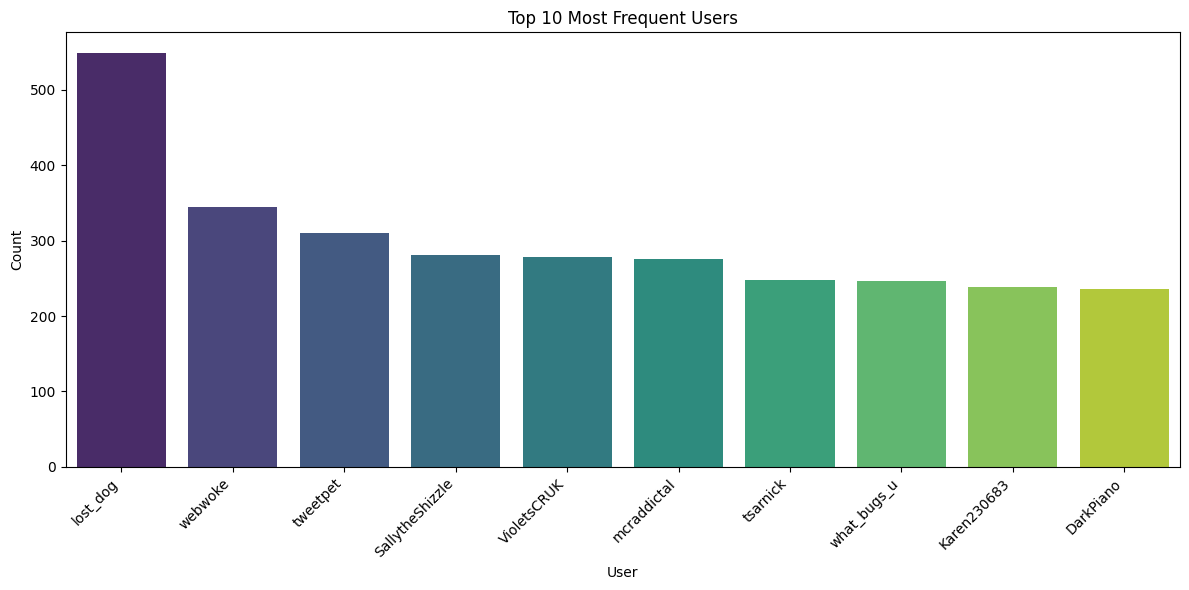

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 most frequent users
top_users = df_sentiment140['user'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_users.index, y=top_users.values, hue=top_users.index, palette='viridis', legend=False)
plt.title('Top 10 Most Frequent Users')
plt.xlabel('User')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
distinct_users_count = df_sentiment140['user'].nunique()
print(f"Total number of unique users: {distinct_users_count}")

Total number of unique users: 659775


In [ ]:
import polars as pl

# Convert pandas DataFrame to Polars DataFrame
pl_df_sentiment140 = pl.DataFrame(df_sentiment140)

print("Pandas DataFrame converted to Polars DataFrame successfully.")

# Display the first 5 rows of the Polars DataFrame
display(pl_df_sentiment140.head())

Pandas DataFrame converted to Polars DataFrame successfully.


sentiment,id,date,query,user,text
i64,i64,datetime[ns],str,str,str
0,1467810369,2009-04-06 22:19:45,"""NO_QUERY""","""_TheSpecialOne_""","""@switchfoot http://twitpic.com…"
0,1467810672,2009-04-06 22:19:49,"""NO_QUERY""","""scotthamilton""","""is upset that he can't update …"
0,1467810917,2009-04-06 22:19:53,"""NO_QUERY""","""mattycus""","""@Kenichan I dived many times f…"
0,1467811184,2009-04-06 22:19:57,"""NO_QUERY""","""ElleCTF""","""my whole body feels itchy and …"
0,1467811193,2009-04-06 22:19:57,"""NO_QUERY""","""Karoli""","""@nationwideclass no, it's not …"


In [ ]:
print(f"Shape of the dataset: {df_sentiment140.shape}")

Shape of the dataset: (1600000, 6)


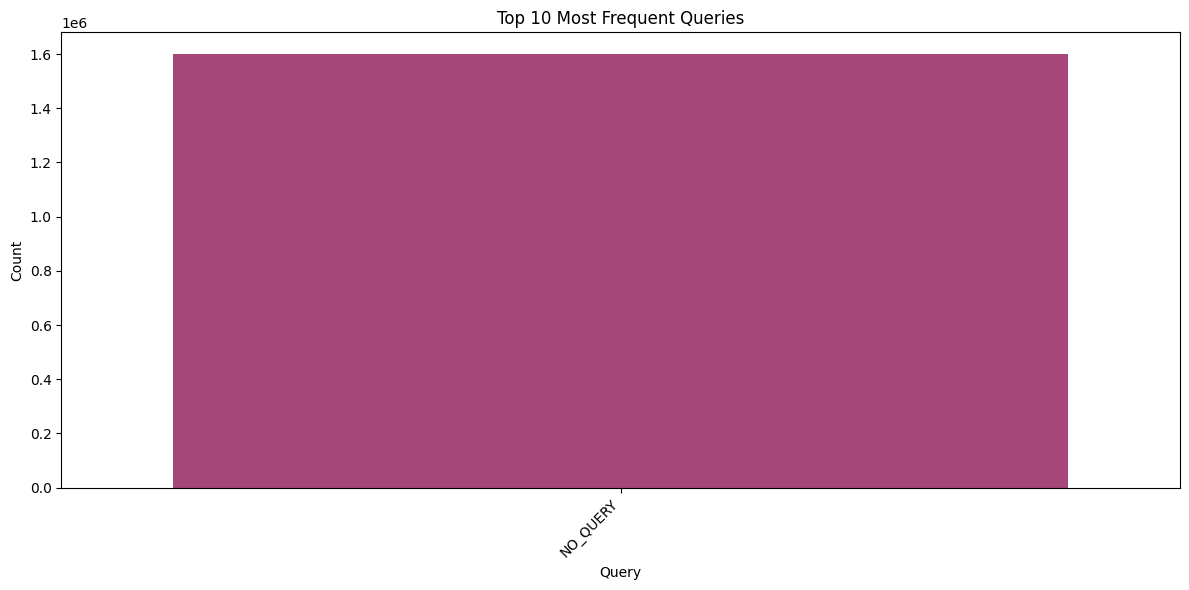

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 most frequent queries
top_queries = df_sentiment140['query'].value_counts().head(10)

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_queries.index, y=top_queries.values, hue=top_queries.index, palette='magma', legend=False)
plt.title('Top 10 Most Frequent Queries')
plt.xlabel('Query')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_sentiment140.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   sentiment  1600000 non-null  int64         
 1   id         1600000 non-null  int64         
 2   date       1600000 non-null  datetime64[ns]
 3   query      1600000 non-null  object        
 4   user       1600000 non-null  object        
 5   text       1600000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 73.2+ MB


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stop words if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtags (#topic)
    text = re.sub(r'#\w+', '', text)

    # 5. Remove punctuation
    text = re.sub(r'[\.,\/#!\$%\^&\*;:{}=\-_`~()"\?]', '', text)

    # 6. Remove numbers (optional, depending on task)
    text = re.sub(r'\d+', '', text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

# Apply the preprocessing function to the 'text' column
df_sentiment140['processed_text'] = df_sentiment140['text'].apply(preprocess_text)

print("Text preprocessing complete. A new column 'processed_text' has been added.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Text preprocessing complete. A new column 'processed_text' has been added.


In [ ]:
# Display original and processed text for a few examples
display(df_sentiment140[['text', 'processed_text']].head())

,text,processed_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",that's bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,upset can't update facebook texting might cry ...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",behaving mad can't see


In [ ]:
import nltk

# Download the 'punkt' tokenizer if not already downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Apply tokenization to the 'processed_text' column
df_sentiment140['tokens'] = df_sentiment140['processed_text'].apply(nltk.word_tokenize)

print("Tokenization complete. A new column 'tokens' has been added.")

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

# Download WordNet resource if not already downloaded
try:
    wordnet.ensure_loaded()
except LookupError:
    nltk.download('wordnet')

# Initialize WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the 'tokens' column
df_sentiment140['lemmas'] = df_sentiment140['tokens'].apply(lemmatize_tokens)

print("Lemmatization complete. A new column 'lemmas' has been added.")

# Display original text, processed text, tokens, and lemmas for a few examples
display(df_sentiment140[['text', 'processed_text', 'tokens', 'lemmas']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...


Lemmatization complete. A new column 'lemmas' has been added.


,text,processed_text,tokens,lemmas
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",that's bummer shoulda got david carr third day,"[that, 's, bummer, shoulda, got, david, carr, ...","[that, 's, bummer, shoulda, got, david, carr, ..."
1,is upset that he can't update his Facebook by ...,upset can't update facebook texting might cry ...,"[upset, ca, n't, update, facebook, texting, mi...","[upset, ca, n't, update, facebook, texting, mi..."
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds,"[dived, many, times, ball, managed, save, rest...","[dived, many, time, ball, managed, save, rest,..."
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feels, itchy, like, fire]","[whole, body, feel, itchy, like, fire]"
4,"@nationwideclass no, it's not behaving at all....",behaving mad can't see,"[behaving, mad, ca, n't, see]","[behaving, mad, ca, n't, see]"


In [ ]:
import nltk

# Download the 'punkt_tab' resource if not already downloaded, as indicated by the traceback
try:
    # Check for 'punkt_tab' (usually a directory or a specific file within it)
    # A common way to check for a collection like 'punkt_tab' is to look for one of its expected files.
    # However, to directly trigger the download based on the error, we'll try to download it directly if not found.
    nltk.data.find('tokenizers/punkt_tab/english.pickle') # Check for a specific file within punkt_tab
except LookupError:
    nltk.download('punkt_tab')

# Apply tokenization to the 'processed_text' column
df_sentiment140['tokens'] = df_sentiment140['processed_text'].apply(nltk.word_tokenize)

print("Tokenization complete. A new column 'tokens' has been added.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Tokenization complete. A new column 'tokens' has been added.


In [ ]:
# Display original text, processed text, and tokens for a few examples
display(df_sentiment140[['text', 'processed_text', 'tokens']].head())

,text,processed_text,tokens
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",that's bummer shoulda got david carr third day,"[that, 's, bummer, shoulda, got, david, carr, ..."
1,is upset that he can't update his Facebook by ...,upset can't update facebook texting might cry ...,"[upset, ca, n't, update, facebook, texting, mi..."
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds,"[dived, many, times, ball, managed, save, rest..."
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire,"[whole, body, feels, itchy, like, fire]"
4,"@nationwideclass no, it's not behaving at all....",behaving mad can't see,"[behaving, mad, ca, n't, see]"


In [ ]:
# Display original text, processed text, and tokens for a few examples
display(df_sentiment140[['text', 'processed_text', 'tokens']].head())

KeyError: "['tokens'] not in index"